In [1]:
# PART E — Controls + Experiment Design
# Cell 1: Define all 5 interventions and print the full structured plan

interventions = [
    {
        'intervention_id': 'E1',
        'intervention_name': 'Hold High-Risk Orders for Manual Review',
        'description': 'Any order with risk_score >= 70 (High band) is automatically held before dispatch and routed to a fraud analyst queue for manual verification within 2 hours.',
        'control_group': '50% of High-risk orders processed normally (no hold)',
        'treatment_group': '50% of High-risk orders held for manual review before dispatch',
        'trigger_condition': 'risk_score >= 70 (High band)',
        'primary_metric': 'Fraud loss prevented (refund_amount + RTO loss avoided in treatment vs control)',
        'secondary_metrics': 'Manual review resolution time; False positive rate (legit orders held)',
        'guardrails': 'Order cancellation rate must not increase >2%; Customer complaint rate must not increase >1%',
        'time_window': '4 weeks',
        'success_threshold': '>= 30% reduction in fraud loss in treatment group vs control',
        'rollback_condition': 'If cancellation rate increases >5% OR NPS drops >10 points',
    },
    {
        'intervention_id': 'E2',
        'intervention_name': 'OTP Verification for COD Orders above Rs 1500',
        'description': 'For all COD orders with net_amount > Rs 1500, send OTP to the registered mobile number. Order only dispatched after OTP confirmation. Targets COD fraud where fake addresses are used.',
        'control_group': 'COD orders > Rs 1500 dispatched without OTP (current behaviour)',
        'treatment_group': 'COD orders > Rs 1500 require OTP confirmation before dispatch',
        'trigger_condition': 'cod_flag = 1 AND net_amount > 1500',
        'primary_metric': 'RTO rate on COD orders > Rs 1500 (treatment vs control)',
        'secondary_metrics': 'OTP completion rate; Delivery success rate; Revenue on COD segment',
        'guardrails': 'COD conversion rate must not drop >5%; OTP failure rate must stay <10%',
        'time_window': '3 weeks',
        'success_threshold': '>= 25% reduction in RTO rate in treatment group',
        'rollback_condition': 'If COD conversion drops >8% indicating significant customer drop-off',
    },
    {
        'intervention_id': 'E3',
        'intervention_name': 'Limit Coupon Usage by Device + Pincode',
        'description': 'Restrict coupon redemption to 1 unique coupon per device_id per 30-day window, and flag if same coupon is used from >3 different user accounts on same pincode. Targets coupon abuse by new account farming.',
        'control_group': 'No coupon restriction (current behaviour)',
        'treatment_group': 'Coupon blocked if device has redeemed same coupon in last 30 days OR pincode has >3 redemptions of same coupon',
        'trigger_condition': 'device_reuse_count >= 3 OR (coupon_id reused > 3 times in same pincode in 30 days)',
        'primary_metric': 'Coupon abuse rate = orders with high_discount_flag / total coupon orders (treatment vs control)',
        'secondary_metrics': 'Coupon redemption volume; Average discount given; Refund rate on coupon orders',
        'guardrails': 'Legitimate coupon conversion rate must not drop >3%; GMV from coupon orders must not drop >5%',
        'time_window': '4 weeks',
        'success_threshold': '>= 40% reduction in high_discount_flag orders in treatment group',
        'rollback_condition': 'If GMV from coupon orders drops >10% suggesting over-blocking',
    },
    {
        'intervention_id': 'E4',
        'intervention_name': 'Blocklist Users with Repeated Payment Failures',
        'description': 'Automatically flag and throttle users who have >= 3 payment failures across any 7-day window. On next order attempt, force a manual CAPTCHA + re-authentication step. Persistent offenders (>5 fails) are soft-blocked for 48 hours.',
        'control_group': 'Users with repeated failures allowed normal checkout (current behaviour)',
        'treatment_group': 'Users with >= 3 failures in 7 days face CAPTCHA + re-auth; >= 5 failures get 48-hour soft block',
        'trigger_condition': 'payment_fail_count_before_success >= 3 within 7-day rolling window',
        'primary_metric': 'Payment fraud loss = orders where multiple failures then suspicious small success (treatment vs control)',
        'secondary_metrics': 'Payment failure rate overall; Legitimate user friction (CAPTCHA completion rate); Checkout abandonment',
        'guardrails': 'Checkout completion rate must not drop >3% for legitimate users; Support tickets must not spike >10%',
        'time_window': '3 weeks',
        'success_threshold': '>= 35% reduction in payment_fail_count orders that result in suspicious successes',
        'rollback_condition': 'If checkout abandonment increases >7% indicating excessive friction for good users',
    },
    {
        'intervention_id': 'E5',
        'intervention_name': 'New User COD Restriction + Address Verification',
        'description': 'For users placing their very first order (new_user_flag=1) with COD payment, enforce: (1) address pin-code deliverability check via logistics API, (2) cap COD order value at Rs 800, (3) send delivery confirmation SMS requiring reply. Targets new account fraud for high-value COD abuse.',
        'control_group': 'New users can place COD orders without restriction (current behaviour)',
        'treatment_group': 'New user COD orders: pincode check + Rs 800 cap + delivery confirmation SMS required',
        'trigger_condition': 'new_user_flag = 1 AND cod_flag = 1',
        'primary_metric': 'RTO rate for new-user COD orders (treatment vs control)',
        'secondary_metrics': 'New user COD conversion rate; Average new-user COD order value; New user repeat order rate',
        'guardrails': 'New user first-order conversion must not drop >5%; New user retention (2nd order) must not drop >3%',
        'time_window': '6 weeks (longer window to capture new user lifecycle)',
        'success_threshold': '>= 30% reduction in RTO rate for new-user COD orders',
        'rollback_condition': 'If new user conversion drops >8% indicating overly aggressive restriction',
    },
]

# Pretty print
print('=' * 80)
print('PART E — CONTROLS + EXPERIMENT DESIGN')
print('5 Interventions with Full A/B Experiment Framework')
print('=' * 80)

for iv in interventions:
    print(f"\n{'─'*70}")
    print(f"[{iv['intervention_id']}] {iv['intervention_name']}")
    print(f"{'─'*70}")
    print(f"Description    : {iv['description']}")
    print(f"Trigger        : {iv['trigger_condition']}")
    print(f"Control Group  : {iv['control_group']}")
    print(f"Treatment Group: {iv['treatment_group']}")
    print(f"Primary Metric : {iv['primary_metric']}")
    print(f"Guardrails     : {iv['guardrails']}")
    print(f"Time Window    : {iv['time_window']}")
    print(f"Success Thresh : {iv['success_threshold']}")
    print(f"Rollback If    : {iv['rollback_condition']}")

print(f"\n{'='*80}")
print('All 5 interventions defined.')

PART E — CONTROLS + EXPERIMENT DESIGN
5 Interventions with Full A/B Experiment Framework

──────────────────────────────────────────────────────────────────────
[E1] Hold High-Risk Orders for Manual Review
──────────────────────────────────────────────────────────────────────
Description    : Any order with risk_score >= 70 (High band) is automatically held before dispatch and routed to a fraud analyst queue for manual verification within 2 hours.
Trigger        : risk_score >= 70 (High band)
Control Group  : 50% of High-risk orders processed normally (no hold)
Treatment Group: 50% of High-risk orders held for manual review before dispatch
Primary Metric : Fraud loss prevented (refund_amount + RTO loss avoided in treatment vs control)
Guardrails     : Order cancellation rate must not increase >2%; Customer complaint rate must not increase >1%
Time Window    : 4 weeks
Success Thresh : >= 30% reduction in fraud loss in treatment group vs control
Rollback If    : If cancellation rate incr

=== EXPERIMENT DESIGN TABLE ===


'intervention_id                               intervention_name                                                                  trigger_condition                                                                                           primary_metric                                           time_window                                                                 success_threshold\n             E1         Hold High-Risk Orders for Manual Review                                                       risk_score >= 70 (High band)                          Fraud loss prevented (refund_amount + RTO loss avoided in treatment vs control)                                               4 weeks                      >= 30% reduction in fraud loss in treatment group vs control\n             E2   OTP Verification for COD Orders above Rs 1500                                                 cod_flag = 1 AND net_amount > 1500                                                  RTO rate on COD orders > 

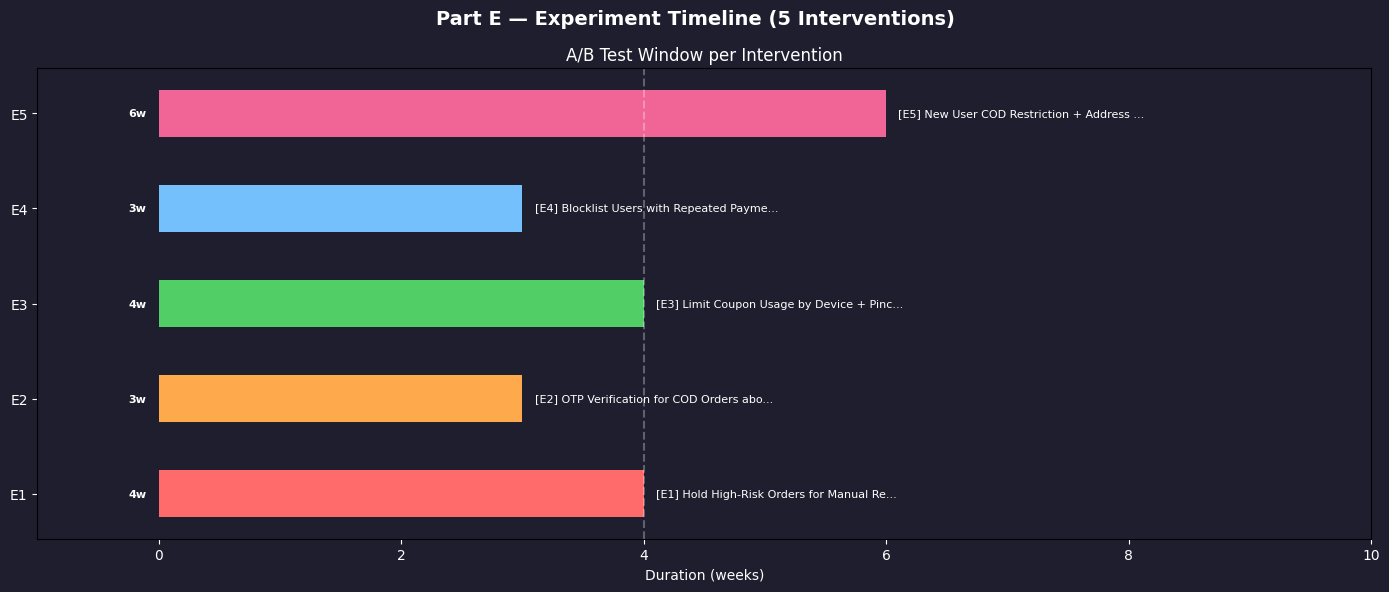

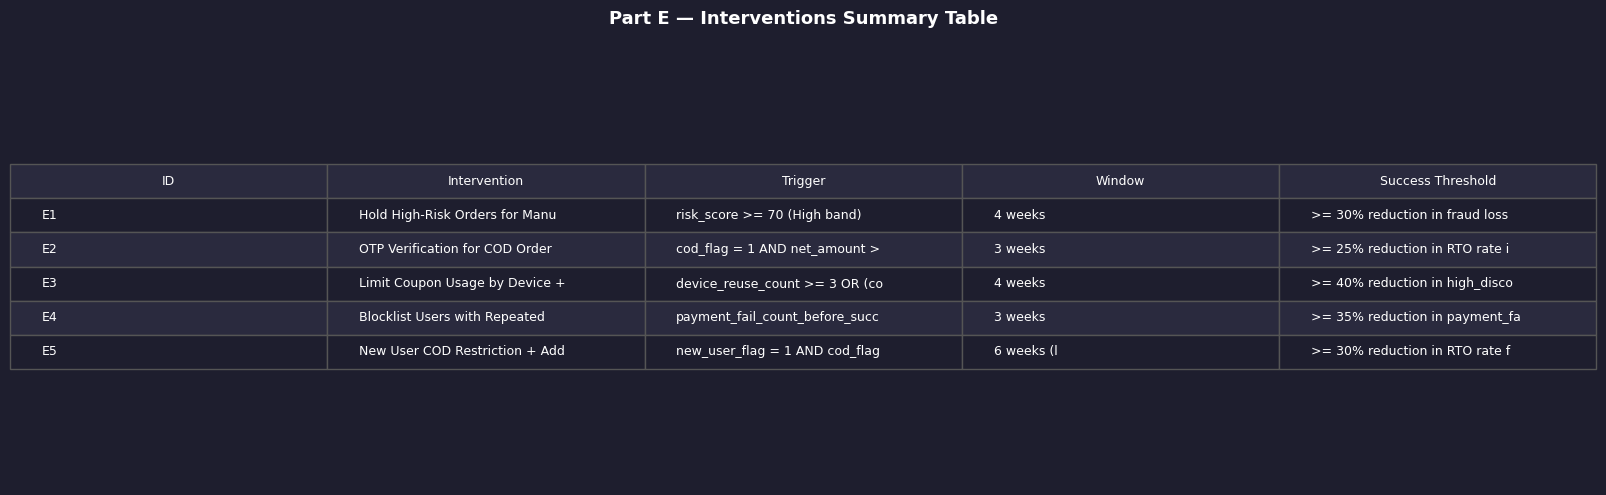


Saved experiment_design_partE.csv with 5 rows x 12 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== PART E COMPLETE ===
5 interventions defined | 2 charts saved | experiment_design_partE.csv downloaded


In [2]:
# CELL 2 — Export to DataFrame, Visualize, and Download CSV
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from google.colab import files

# Build DataFrame
df = pd.DataFrame(interventions)

# Display full table
print('=== EXPERIMENT DESIGN TABLE ===')
display(df[['intervention_id','intervention_name','trigger_condition',
            'primary_metric','time_window','success_threshold']].to_string(index=False))

# --- Visualization: Experiment Timeline ---
plt.rcParams['figure.facecolor'] = '#1e1e2e'
plt.rcParams['axes.facecolor']   = '#1e1e2e'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Part E — Experiment Timeline (5 Interventions)', fontsize=14,
             color='white', fontweight='bold')

colors = ['#ff6b6b','#ffa94d','#51cf66','#74c0fc','#f06595']
tw_map = {'3 weeks': 3, '4 weeks': 4,
          '6 weeks (longer window to capture new user lifecycle)': 6}

for i, iv in enumerate(interventions):
    duration = tw_map.get(iv['time_window'], 4)
    ax.barh(i, duration, color=colors[i], height=0.5, left=0)
    ax.text(duration + 0.1, i,
            f"[{iv['intervention_id']}] {iv['intervention_name'][:35]}...",
            va='center', color='white', fontsize=8)
    ax.text(-0.1, i, f"{duration}w", va='center', ha='right',
            color='white', fontsize=8, fontweight='bold')

ax.set_yticks(range(len(interventions)))
ax.set_yticklabels([iv['intervention_id'] for iv in interventions])
ax.set_xlabel('Duration (weeks)')
ax.set_title('A/B Test Window per Intervention', color='white')
ax.set_xlim(-1, 10)
ax.axvline(x=4, color='white', linestyle='--', alpha=0.3, label='4-week mark')

plt.tight_layout()
plt.savefig('partE_experiment_timeline.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Visualization 2: Intervention Summary Table as Figure ---
fig2, ax2 = plt.subplots(figsize=(16, 5))
fig2.patch.set_facecolor('#1e1e2e')
ax2.axis('off')

table_data = [
    [iv['intervention_id'], iv['intervention_name'][:30], iv['trigger_condition'][:30],
     iv['time_window'][:10], iv['success_threshold'][:30]]
    for iv in interventions
]
cols = ['ID', 'Intervention', 'Trigger', 'Window', 'Success Threshold']
tbl = ax2.table(cellText=table_data, colLabels=cols, loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor('#2a2a3e' if row % 2 == 0 else '#1e1e2e')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#555')
fig2.suptitle('Part E — Interventions Summary Table', fontsize=13,
              color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('partE_summary_table.png', dpi=120, bbox_inches='tight')
plt.show()

# Save CSV
df.to_csv('/content/experiment_design_partE.csv', index=False)
print(f'\nSaved experiment_design_partE.csv with {len(df)} rows x {len(df.columns)} columns')

# Download
files.download('/content/experiment_design_partE.csv')
print('\n=== PART E COMPLETE ===')
print('5 interventions defined | 2 charts saved | experiment_design_partE.csv downloaded')